In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import sqlite3

class RealEstateScraper:
    def __init__(self, base_url, db_file):
        self.base_url = base_url
        self.db_file = db_file

        # データベースの初期設定
        self.init_db()

    def init_db(self):
        conn = sqlite3.connect(self.db_file)  
        c = conn.cursor()

        # テーブル作成
        c.execute('''
        CREATE TABLE IF NOT EXISTS suumo_properties (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT,
            distance TEXT,
            price TEXT
        )
        ''')

        conn.commit()
        conn.close()

    def get_property_data(self, max_pages=1):
        properties = []
        for page_number in range(1, max_pages + 1):
            page_url = self.base_url + f'?page={page_number}'
            response = requests.get(page_url)
            response.raise_for_status()

            soup = BeautifulSoup(response.text, 'html.parser')
            if not soup.find_all('div', class_='cassetteitem'):
                break

            for listing in soup.find_all('div', class_='cassetteitem'):
                name = listing.find('div', class_='cassetteitem_content-title').get_text(strip=True)
                distances = listing.find_all('div', class_='cassetteitem_detail-text')
                price_tags = listing.find_all('span', class_='cassetteitem_other-emphasis')

                if distances and price_tags:
                    distance_texts = [dist.get_text(strip=True) for dist in distances]
                    price_texts = [price.get_text(strip=True) for price in price_tags]

                    properties.append({
                        'name': name,
                        'distance': distance_texts[0],
                        'price': price_texts[0]
                    })
            time.sleep(1)  
        self.df = pd.DataFrame(properties)

    def save_to_db(self):
        conn = sqlite3.connect(self.db_file)  
        self.df.to_sql('suumo_properties', conn, if_exists='append', index=False)
        conn.close()
        print("データはデータベースに保存されました。")

# スクレイピングとデータベースに保存の実行
scraper = RealEstateScraper('https://suumo.jp/jj/chintai/ichiran/FR301FC001/?ar=030&bs=040&ra=013&cb=0.0&ct=9999999&et=9999999&cn=9999999&mb=0&mt=9999999&shkr1=03&shkr2=03&shkr3=03&shkr4=03&fw2=&ek=030538740&rn=0305&srch_navi=1', 'suumo.db')
scraper.get_property_data(max_pages=10)  
scraper.save_to_db()

データはデータベースに保存されました。


In [56]:
import re
import pandas as pd
import sqlite3

db_path = 'suumo.db'
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM suumo_properties", conn)
conn.close()

# データの初期確認
print("Initial Data:")
print(df.head(20))  

def extract_distance(value):
    if value is None:
        return None
    if isinstance(value, str):
        match = re.search(r'歩(\d+)分', value)
        if match:
            return int(match.group(1))
        else:
            print(f"Cannot extract distance from value: {value}")
    return None


def extract_price(value):
    try:
        return float(value.replace('万円', '').replace(',', ''))
    except Exception as e:
        print(f"Error converting value: {value}. Error: {e}")
        return None


df['distance'] = df['distance'].apply(extract_distance)
df['price'] = df['price'].apply(extract_price)

df = df.dropna(subset=['distance', 'price'])

print("Cleaned Data:")
print(df.head(20))
print(df.describe())
         

Initial Data:
    id                  name         distance   price
0    1   ＪＲ中央線 武蔵境駅 2階建 築29年   ＪＲ中央線/武蔵境駅 歩5分    11万円
1    2   ＪＲ中央線 武蔵境駅 3階建 築16年   ＪＲ中央線/武蔵境駅 歩9分  11.2万円
2    3               トレビナ武蔵野   ＪＲ中央線/武蔵境駅 歩9分  11.2万円
3    4                   リアン   ＪＲ中央線/武蔵境駅 歩6分    16万円
4    5            ドゥジェーム・ニイヤ  ＪＲ中央線/武蔵境駅 歩18分    13万円
5    6   ＪＲ中央線 武蔵境駅 2階建 築11年  ＪＲ中央線/武蔵境駅 歩11分  13.8万円
6    7               パナックスII  ＪＲ中央線/武蔵境駅 歩11分  13.8万円
7    8   ＪＲ中央線 武蔵境駅 4階建 築21年   ＪＲ中央線/武蔵境駅 歩9分   8.5万円
8    9             フレールかえで通り   ＪＲ中央線/武蔵境駅 歩9分   8.5万円
9   10               ル・ボワ武蔵境  西武多摩川線/武蔵境駅 歩6分   8.9万円
10  11  ＪＲ中央線 武蔵境駅 10階建 築28年   ＪＲ中央線/武蔵境駅 歩2分  16.8万円
11  12              Ｎａｓｉｃ武蔵境  ＪＲ中央線/武蔵境駅 歩15分   6.1万円
12  13             ブリリアントパレス   ＪＲ中央線/武蔵境駅 歩2分    19万円
13  14   ＪＲ中央線 武蔵境駅 5階建 築30年   ＪＲ中央線/武蔵境駅 歩7分  21.9万円
14  15          ＫＤＸレジデンス武蔵境I   ＪＲ中央線/武蔵境駅 歩5分  22.3万円
15  16                  木路々館   ＪＲ中央線/武蔵境駅 歩9分   5.1万円
16  17   ＪＲ中央線 武蔵境駅 2階建 築17年  ＪＲ中央線/武蔵境駅 歩20分   7.8万円
17  18   ＪＲ中央線

In [57]:
# 基本統計量の確認
print(df.describe())

               id    distance       price
count  600.000000  600.000000  600.000000
mean   300.500000    9.616667   11.256667
std    173.349358    4.289568    4.806623
min      1.000000    2.000000    4.800000
25%    150.750000    6.000000    7.800000
50%    300.500000    9.000000    8.850000
75%    450.250000   12.000000   13.800000
max    600.000000   22.000000   22.300000


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Fon

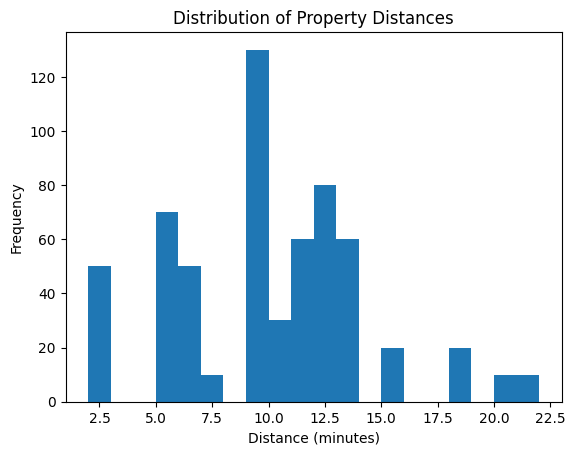

findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Fon

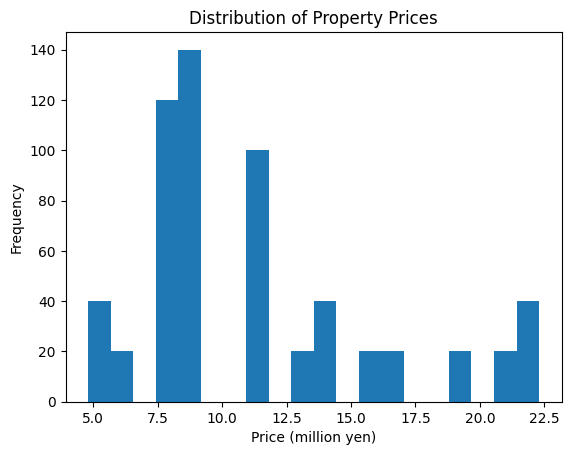

In [58]:
import matplotlib.pyplot as plt

# 'distance' のヒストグラム
plt.hist(df['distance'], bins=20)
plt.xlabel('Distance (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Property Distances')
plt.show()

# 'price' のヒストグラム
plt.hist(df['price'], bins=20)
plt.xlabel('Price (million yen)')
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices')
plt.show()

findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Fon

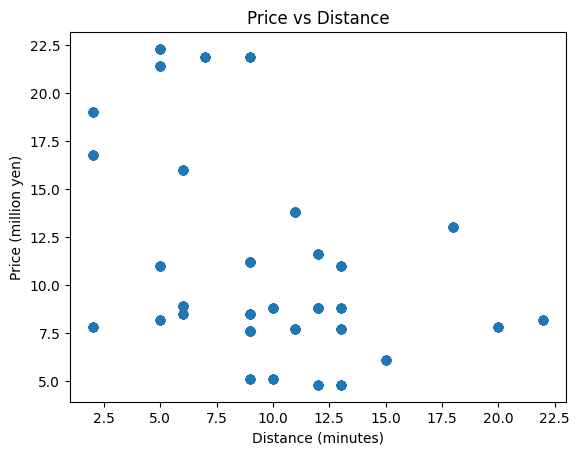

In [59]:
# 'distance' と 'price' の散布図
plt.scatter(df['distance'], df['price'])
plt.xlabel('Distance (minutes)')
plt.ylabel('Price (million yen)')
plt.title('Price vs Distance')
plt.show()